# BIKE SHARE DEMAND FORECASTING - IMPROVED MODEL
## Spatio-Temporal Graph Attention Network (ST-GAT)

By Dipayita Basu (2404107021), Haadiya Iman (2404107026)

In [2]:
try:
    import torch_geometric
    from torch_geometric.nn import GATConv
    from torch_geometric.utils import dense_to_sparse
    print("✓ PyTorch Geometric already installed!")
except ImportError:
    print("Installing PyTorch Geometric (this may take 2-3 minutes)...")
    !pip install -q torch-geometric
    print("✓ Installation complete! Now restart runtime and run again.")
    # Stop here - user needs to restart
    import sys
    sys.exit()

Installing PyTorch Geometric (this may take 2-3 minutes)...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.1 MB/s eta 0:00:00


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



✓ Installation complete! Now restart runtime and run again.
Traceback (most recent call last):
  File "/tmp/ipython-input-2627208614.py", line 2, in <cell line: 0>
    import torch_geometric
ModuleNotFoundError: No module named 'torch_geometric'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-2627208614.py", line 12, in <cell line: 0>
    sys.exit()
SystemExit

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/ultratb.py", line 1101, in get_records
    return _fixed_getinnerframes(etb, number_of_lines_of_context, tb_offset)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/

TypeError: object of type 'NoneType' has no len()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import torch
from datetime import datetime
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error,mean_absolute_error, r2_score
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch_geometric.nn import GATConv
from torch_geometric.utils import dense_to_sparse

warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:
trips = pd.read_csv('trip.csv')
stations = pd.read_csv('station.csv')
weather = pd.read_csv('weather.csv')

print(f"Trips: {len(trips):,} records")
print(f"Stations: {len(stations):,} stations")
print(f"Weather: {len(weather):,} records")


Trips: 27,256 records
Stations: 70 stations
Weather: 3,665 records


In [5]:
# basic info

print("TRIP DATA STRUCTURE")
print(trips.head())
print("\nColumns:", trips.columns.tolist())
print("\nData types:")
print(trips.dtypes)

TRIP DATA STRUCTURE
     id  duration       start_date        start_station_name  \
0  4576      63.0  8/29/2013 14:13  South Van Ness at Market   
1  4607      70.0  8/29/2013 14:42        San Jose City Hall   
2  4130      71.0  8/29/2013 10:16   Mountain View City Hall   
3  4251      77.0  8/29/2013 11:29        San Jose City Hall   
4  4299      83.0  8/29/2013 12:02  South Van Ness at Market   

   start_station_id         end_date          end_station_name  \
0              66.0  8/29/2013 14:14  South Van Ness at Market   
1              10.0  8/29/2013 14:43        San Jose City Hall   
2              27.0  8/29/2013 10:17   Mountain View City Hall   
3              10.0  8/29/2013 11:30        San Jose City Hall   
4              66.0  8/29/2013 12:04            Market at 10th   

   end_station_id  bike_id subscription_type zip_code  
0            66.0    520.0        Subscriber    94127  
1            10.0    661.0        Subscriber    95138  
2            27.0     48.0    

In [6]:
print("STATION DATA STRUCTURE")
print(stations.head())
print("\nColumns:", stations.columns.tolist())

STATION DATA STRUCTURE
   id                               name        lat        long  dock_count  \
0   2  San Jose Diridon Caltrain Station  37.329732 -121.901782          27   
1   3              San Jose Civic Center  37.330698 -121.888979          15   
2   4             Santa Clara at Almaden  37.333988 -121.894902          11   
3   5                   Adobe on Almaden  37.331415 -121.893200          19   
4   6                   San Pedro Square  37.336721 -121.894074          15   

       city installation_date  
0  San Jose          8/6/2013  
1  San Jose          8/5/2013  
2  San Jose          8/6/2013  
3  San Jose          8/5/2013  
4  San Jose          8/7/2013  

Columns: ['id', 'name', 'lat', 'long', 'dock_count', 'city', 'installation_date']


In [7]:
print("WEATHER DATA STRUCTURE")
print(weather.head())
print("\nColumns:", weather.columns.tolist())

WEATHER DATA STRUCTURE
        date  max_temperature_f  mean_temperature_f  min_temperature_f  \
0  8/29/2013               74.0                68.0               61.0   
1  8/30/2013               78.0                69.0               60.0   
2  8/31/2013               71.0                64.0               57.0   
3   9/1/2013               74.0                66.0               58.0   
4   9/2/2013               75.0                69.0               62.0   

   max_dew_point_f  mean_dew_point_f  min_dew_point_f  max_humidity  \
0             61.0              58.0             56.0          93.0   
1             61.0              58.0             56.0          90.0   
2             57.0              56.0             54.0          93.0   
3             60.0              56.0             53.0          87.0   
4             61.0              60.0             58.0          93.0   

   mean_humidity  min_humidity  ...  mean_visibility_miles  \
0           75.0          57.0  ...        

### DATA CLEANING AND PREPROCESSING

### a - trips dataset

In [8]:
# converting datetime columns

trips['start_date'] = pd.to_datetime(trips['start_date'])
trips['end_date'] = pd.to_datetime(trips['end_date'])
print("Datetime conversion complete")


Datetime conversion complete


In [9]:
# calculating trip duration in minutes

trips['duration_minutes'] = trips['duration'] / 60
print("Duration calculated")

Duration calculated


In [10]:
trips.head(2)

,id,duration,start_date,start_station_name,start_station_id,end_date,end_station_name,end_station_id,bike_id,subscription_type,zip_code,duration_minutes
0,4576,63.0,2013-08-29 14:13:00,South Van Ness at Market,66.0,2013-08-29 14:14:00,South Van Ness at Market,66.0,520.0,Subscriber,94127,1.050000
1,4607,70.0,2013-08-29 14:42:00,San Jose City Hall,10.0,2013-08-29 14:43:00,San Jose City Hall,10.0,661.0,Subscriber,95138,1.166667


In [11]:
# checking for missing values

missing = trips.isnull().sum()
if missing.sum() > 0:
    print("Missing values found:")
    print(missing[missing > 0])
else:
    print("No missing values")

Missing values found:
duration                 1
start_date               1
start_station_name       1
start_station_id         1
end_date                 1
end_station_name         1
end_station_id           1
bike_id                  1
subscription_type        1
zip_code              2053
duration_minutes         1
dtype: int64


This is about 1% of the data. we can remove these rows

In [12]:
# removing rows with the missing zipcode values
original_len = len(trips)
trips = trips.dropna()
removed = original_len - len(trips)

if removed > 0:
    print(f"\nRemoved {removed:,} rows with missing values ({removed/original_len*100:.2f}%)")
    print(f"Remaining trips: {len(trips):,} ({len(trips)/original_len*100:.1f}% of original data)")
else:
    print("No missing values")


Removed 2,053 rows with missing values (7.53%)
Remaining trips: 25,203 (92.5% of original data)


In [13]:
# analyze outliers

original_count = len(trips)

# the distribution of durations
print(f"\nDuration statistics (in minutes):")
print(trips['duration_minutes'].describe())



Duration statistics (in minutes):
count    25203.000000
mean        24.527796
std        120.180320
min          1.000000
25%          6.633333
50%         10.383333
75%         16.266667
max       9958.616667
Name: duration_minutes, dtype: float64


In [14]:
# Check for extreme values
print(f"\n  Extreme values:")
print(f"- Trips < 1 minute: {len(trips[trips['duration_minutes'] < 1]):,}")
print(f"- Trips > 60 minutes: {len(trips[trips['duration_minutes'] > 60]):,}")
print(f"- Trips > 180 minutes (3 hrs): {len(trips[trips['duration_minutes'] > 180]):,}")
print(f"- Maximum duration: {trips['duration_minutes'].max():.1f} minutes ({trips['duration_minutes'].max()/60:.1f} hours)")


  Extreme values:
- Trips < 1 minute: 0
- Trips > 60 minutes: 1,336
- Trips > 180 minutes (3 hrs): 501
- Maximum duration: 9958.6 minutes (166.0 hours)


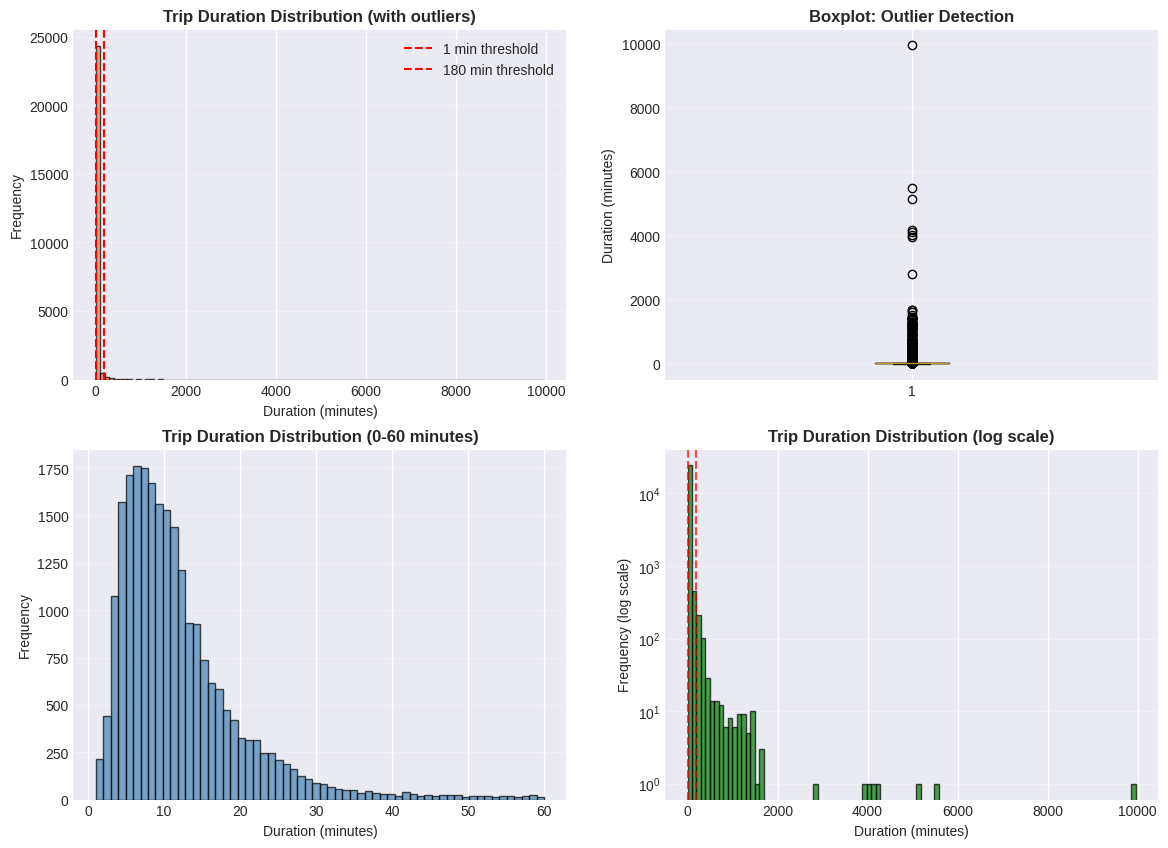

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# full distribution with outliers
ax1 = axes[0, 0]
ax1.hist(trips['duration_minutes'], bins=100, color='coral', edgecolor='black', alpha=0.7)
ax1.set_title('Trip Duration Distribution (with outliers)', fontweight='bold')
ax1.set_xlabel('Duration (minutes)')
ax1.set_ylabel('Frequency')
ax1.axvline(x=1, color='red', linestyle='--', label='1 min threshold')
ax1.axvline(x=180, color='red', linestyle='--', label='180 min threshold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# box plot for showing outliers
ax2 = axes[0, 1]
ax2.boxplot(trips['duration_minutes'], vert=True)
ax2.set_title('Boxplot: Outlier Detection', fontweight='bold')
ax2.set_ylabel('Duration (minutes)')
ax2.grid(axis='y', alpha=0.3)

# zoomed in distribution
ax3 = axes[1, 0]
trips_subset = trips[trips['duration_minutes'] <= 60]
ax3.hist(trips_subset['duration_minutes'], bins=60, color='steelblue', edgecolor='black', alpha=0.7)
ax3.set_title('Trip Duration Distribution (0-60 minutes)', fontweight='bold')
ax3.set_xlabel('Duration (minutes)')
ax3.set_ylabel('Frequency')
ax3.grid(axis='y', alpha=0.3)

# log scale distribution
ax4 = axes[1, 1]
ax4.hist(trips['duration_minutes'], bins=100, color='green', edgecolor='black', alpha=0.7)
ax4.set_yscale('log')
ax4.set_title('Trip Duration Distribution (log scale)', fontweight='bold')
ax4.set_xlabel('Duration (minutes)')
ax4.set_ylabel('Frequency (log scale)')
ax4.axvline(x=1, color='red', linestyle='--', alpha=0.7)
ax4.axvline(x=180, color='red', linestyle='--', alpha=0.7)
ax4.grid(axis='y', alpha=0.3)

In [16]:
# calculate percentiles
print(f"\nPercentile analysis:")
percentiles = [1, 25, 50, 75, 95, 99.9]
for p in percentiles:
    value = np.percentile(trips['duration_minutes'], p)
    print(f"- {p}th percentile: {value:.1f} minutes")


Percentile analysis:
- 1th percentile: 2.1 minutes
- 25th percentile: 6.6 minutes
- 50th percentile: 10.4 minutes
- 75th percentile: 16.3 minutes
- 95th percentile: 65.1 minutes
- 99.9th percentile: 1315.1 minutes


- defining reasonable thresholds:
- lower bound: 1 minute (could be some data errors or cancelled trips)
- upper bound: 180 minutes (3 hours - beyond this is could be lost or stolen bikes or errors)

In [17]:
# remove trips shorter than 1 minute or longer than 3 hours
trips = trips[(trips['duration_minutes'] >= 1) &
              (trips['duration_minutes'] <= 180)]

removed_count = original_count - len(trips)
print(f"Removed {removed_count:,} outlier trips ({removed_count/original_count*100:.2f}%)")
print(f"Remaining trips: {len(trips):,} ({len(trips)/original_count*100:.1f}% of data)")

Removed 501 outlier trips (1.99%)
Remaining trips: 24,702 (98.0% of data)


In [18]:
# cleaned distribution
print(f"\nCleaned data statistics:")
print(trips['duration_minutes'].describe())


Cleaned data statistics:
count    24702.000000
mean        15.169640
std         19.620823
min          1.000000
25%          6.550000
50%         10.216667
75%         15.700000
max        179.483333
Name: duration_minutes, dtype: float64


### b - stations dataset

In [19]:
stations.head(2)

,id,name,lat,long,dock_count,city,installation_date
0,2,San Jose Diridon Caltrain Station,37.329732,-121.901782,27,San Jose,8/6/2013
1,3,San Jose Civic Center,37.330698,-121.888979,15,San Jose,8/5/2013


In [20]:
print("STATION DATA STRUCTURE")
print(stations.head())
print("\nColumns:", stations.columns.tolist())
print("\nData types:")
print(stations.dtypes)

STATION DATA STRUCTURE
   id                               name        lat        long  dock_count  \
0   2  San Jose Diridon Caltrain Station  37.329732 -121.901782          27   
1   3              San Jose Civic Center  37.330698 -121.888979          15   
2   4             Santa Clara at Almaden  37.333988 -121.894902          11   
3   5                   Adobe on Almaden  37.331415 -121.893200          19   
4   6                   San Pedro Square  37.336721 -121.894074          15   

       city installation_date  
0  San Jose          8/6/2013  
1  San Jose          8/5/2013  
2  San Jose          8/6/2013  
3  San Jose          8/5/2013  
4  San Jose          8/7/2013  

Columns: ['id', 'name', 'lat', 'long', 'dock_count', 'city', 'installation_date']

Data types:
id                     int64
name                  object
lat                  float64
long                 float64
dock_count             int64
city                  object
installation_date     object
dtype: obje

In [21]:
# Basic station statistics
print(f"\nStation Statistics:")
print(f"- Total stations: {len(stations)}")
print(f"- Cities covered: {stations['city'].nunique()}")
print(f"- Cities: {', '.join(stations['city'].unique())}")
print(f"- Total dock capacity: {stations['dock_count'].sum():,}")
print(f"- Avg docks per station: {stations['dock_count'].mean():.1f}")


Station Statistics:
- Total stations: 70
- Cities covered: 5
- Cities: San Jose, Redwood City, Mountain View, Palo Alto, San Francisco
- Total dock capacity: 1,236
- Avg docks per station: 17.7


In [22]:
# check for missing values in stations

station_missing = stations.isnull().sum()

In [23]:
station_missing

,0
id,0
name,0
lat,0
long,0
dock_count,0
city,0
installation_date,0


In [24]:
# check for duplicate stations

duplicate_stations = stations.duplicated(subset=['id']).sum()
if duplicate_stations > 0:
    print(f"Found {duplicate_stations} duplicate station IDs")
    stations = stations.drop_duplicates(subset=['id'], keep='first')
    print(f"Removed duplicates. Final count: {len(stations)}")
else:
    print(f"No duplicate stations found")

No duplicate stations found


In [25]:
# station summary

station_summary = stations.groupby('city').agg({'id': 'count','dock_count': ['sum', 'mean', 'min',
                                                                             'max']}).round(1)
station_summary.columns = ['Stations', 'Total Docks', 'Avg Docks', 'Min Docks', 'Max Docks']
print("\n" + station_summary.to_string())


               Stations  Total Docks  Avg Docks  Min Docks  Max Docks
city                                                                 
Mountain View         7          117       16.7         11         23
Palo Alto             5           75       15.0         11         23
Redwood City          7          115       16.4         15         25
San Francisco        35          665       19.0         15         27
San Jose             16          264       16.5         11         27


In [26]:
# check if the station IDs in trips exist in station data

valid_station_ids = set(stations['id'])
invalid_start = trips[~trips['start_station_id'].isin(valid_station_ids)]
invalid_end = trips[~trips['end_station_id'].isin(valid_station_ids)]


if len(invalid_start) > 0:
    print(f"Found {len(invalid_start)} trips with invalid start station IDs")
    print(f"Invalid IDs: {invalid_start['start_station_id'].unique()}")
    trips = trips[trips['start_station_id'].isin(valid_station_ids)]

if len(invalid_end) > 0:
    print(f"Found {len(invalid_end)} trips with invalid end station IDs")
    print(f"Invalid IDs: {invalid_end['end_station_id'].unique()}")
    trips = trips[trips['end_station_id'].isin(valid_station_ids)]

if len(invalid_start) == 0 and len(invalid_end) == 0:
    print("All trip station IDs are valid")
else:
    print(f"Removed trips with invalid stations. Remaining: {len(trips):,}")

All trip station IDs are valid


### FEATURE ENGINEERING

In [27]:
# Extract time-based features
trips['hour'] = trips['start_date'].dt.hour
trips['day_of_week'] = trips['start_date'].dt.dayofweek  # 0 = monday, 1 = tuesday
trips['day_name'] = trips['start_date'].dt.day_name()
trips['month'] = trips['start_date'].dt.month
trips['year'] = trips['start_date'].dt.year
trips['date'] = trips['start_date'].dt.date
trips['is_weekend'] = trips['day_of_week'].isin([5, 6]).astype(int) # 0 for no, 1 for yes


In [28]:
trips.head(2)

,id,duration,start_date,start_station_name,start_station_id,end_date,end_station_name,end_station_id,bike_id,subscription_type,zip_code,duration_minutes,hour,day_of_week,day_name,month,year,date,is_weekend
0,4576,63.0,2013-08-29 14:13:00,South Van Ness at Market,66.0,2013-08-29 14:14:00,South Van Ness at Market,66.0,520.0,Subscriber,94127,1.050000,14,3,Thursday,8,2013,2013-08-29,0
1,4607,70.0,2013-08-29 14:42:00,San Jose City Hall,10.0,2013-08-29 14:43:00,San Jose City Hall,10.0,661.0,Subscriber,95138,1.166667,14,3,Thursday,8,2013,2013-08-29,0


In [29]:
# creating time period categories
def get_time_period(hour):
    if 6 <= hour < 9:
        return 'Morning Rush'
    elif 9 <= hour < 12:
        return 'Late Morning'
    elif 12 <= hour < 14:
        return 'Lunch'
    elif 14 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 20:
        return 'Evening Rush'
    elif 20 <= hour < 23:
        return 'Evening'
    else:
        return 'Night'

trips['time_period'] = trips['hour'].apply(get_time_period)

print("Temporal features created:")
print("- hour, day_of_week, day_name, month, year")
print("- is_weekend, time_period")


Temporal features created:
- hour, day_of_week, day_name, month, year
- is_weekend, time_period


In [30]:
trips.head(2)

,id,duration,start_date,start_station_name,start_station_id,end_date,end_station_name,end_station_id,bike_id,subscription_type,zip_code,duration_minutes,hour,day_of_week,day_name,month,year,date,is_weekend,time_period
0,4576,63.0,2013-08-29 14:13:00,South Van Ness at Market,66.0,2013-08-29 14:14:00,South Van Ness at Market,66.0,520.0,Subscriber,94127,1.050000,14,3,Thursday,8,2013,2013-08-29,0,Afternoon
1,4607,70.0,2013-08-29 14:42:00,San Jose City Hall,10.0,2013-08-29 14:43:00,San Jose City Hall,10.0,661.0,Subscriber,95138,1.166667,14,3,Thursday,8,2013,2013-08-29,0,Afternoon


In [31]:
# Cyclic Encoding of Existing Time Features
# Cyclic encoding for hour of day
trips['hour_sin'] = np.sin(2 * np.pi * trips['hour'] / 24)
trips['hour_cos'] = np.cos(2 * np.pi * trips['hour'] / 24)

# Cyclic encoding for day of week
trips['dow_sin'] = np.sin(2 * np.pi * trips['day_of_week'] / 7)
trips['dow_cos'] = np.cos(2 * np.pi * trips['day_of_week'] / 7)

print("Cyclic time features (hour_sin, hour_cos, dow_sin, dow_cos) added.")


Cyclic time features (hour_sin, hour_cos, dow_sin, dow_cos) added.


In [32]:
trips.head(2)

,id,duration,start_date,start_station_name,start_station_id,end_date,end_station_name,end_station_id,bike_id,subscription_type,...,day_name,month,year,date,is_weekend,time_period,hour_sin,hour_cos,dow_sin,dow_cos
0,4576,63.0,2013-08-29 14:13:00,South Van Ness at Market,66.0,2013-08-29 14:14:00,South Van Ness at Market,66.0,520.0,Subscriber,...,Thursday,8,2013,2013-08-29,0,Afternoon,-0.5,-0.866025,0.433884,-0.900969
1,4607,70.0,2013-08-29 14:42:00,San Jose City Hall,10.0,2013-08-29 14:43:00,San Jose City Hall,10.0,661.0,Subscriber,...,Thursday,8,2013,2013-08-29,0,Afternoon,-0.5,-0.866025,0.433884,-0.900969


## Exploratory Data Analysis

In [33]:
# basic statistics

print("TRIP DURATION STATISTICS")
print(trips['duration_minutes'].describe())

TRIP DURATION STATISTICS
count    24702.000000
mean        15.169640
std         19.620823
min          1.000000
25%          6.550000
50%         10.216667
75%         15.700000
max        179.483333
Name: duration_minutes, dtype: float64


In [34]:
# 4.2 Temporal patterns

print("TEMPORAL DISTRIBUTION")

print("\nTrips by day of week:")
print(trips['day_name'].value_counts().sort_index())

print("\nWeekday vs Weekend:")
weekend_trips = trips['is_weekend'].value_counts()
print(f"Weekday: {weekend_trips[0]:,} ({weekend_trips[0]/len(trips)*100:.1f}%)")
print(f"Weekend: {weekend_trips[1]:,} ({weekend_trips[1]/len(trips)*100:.1f}%)")

print("\nTrips by time period:")
print(trips['time_period'].value_counts().sort_index())


TEMPORAL DISTRIBUTION

Trips by day of week:
day_name
Friday       4314
Monday       3924
Saturday     2677
Sunday       2651
Thursday     4202
Tuesday      3325
Wednesday    3609
Name: count, dtype: int64

Weekday vs Weekend:
Weekday: 19,374 (78.4%)
Weekend: 5,328 (21.6%)

Trips by time period:
time_period
Afternoon       5200
Evening         1697
Evening Rush    5850
Late Morning    4170
Lunch           3926
Morning Rush    3292
Night            567
Name: count, dtype: int64


In [35]:
# 4.3 Station statistics

print("STATION STATISTICS")

start_counts = trips['start_station_id'].value_counts()
end_counts = trips['end_station_id'].value_counts()

print(f"\nMost popular start stations:")
print(start_counts.head(10))

print(f"\nMost popular end stations:")
print(end_counts.head(10))

STATION STATISTICS

Most popular start stations:
start_station_id
50.0    1368
70.0    1318
60.0    1301
77.0    1040
74.0     857
61.0     849
76.0     804
65.0     753
66.0     746
64.0     732
Name: count, dtype: int64

Most popular end stations:
end_station_id
60.0    1490
70.0    1474
50.0    1376
77.0     998
61.0     900
76.0     888
74.0     836
65.0     821
64.0     797
69.0     736
Name: count, dtype: int64


### c - Weather DataSet

In [36]:
weather.describe()

,max_temperature_f,mean_temperature_f,min_temperature_f,max_dew_point_f,mean_dew_point_f,min_dew_point_f,max_humidity,mean_humidity,min_humidity,max_sea_level_pressure_inches,...,min_sea_level_pressure_inches,max_visibility_miles,mean_visibility_miles,min_visibility_miles,max_wind_Speed_mph,mean_wind_speed_mph,max_gust_speed_mph,cloud_cover,wind_dir_degrees,zip_code
count,3661.000000,3661.000000,3661.000000,3611.000000,3611.000000,3611.000000,3611.000000,3611.000000,3611.000000,3664.000000,...,3664.000000,3652.000000,3652.000000,3652.000000,3664.000000,3664.000000,2766.000000,3664.000000,3664.000000,3665.000000
mean,70.580989,61.348812,51.947282,53.149820,48.794794,44.306840,85.446968,67.256993,46.458045,30.074997,...,29.965835,10.555312,9.822015,8.229737,16.398472,5.962063,22.299349,2.784389,266.605895,94325.000000
std,8.385572,7.234397,7.441444,6.885449,7.822281,9.355432,9.226972,10.945591,14.434784,0.134492,...,0.133476,2.193828,1.469894,2.862132,7.787588,3.340603,9.618813,2.276401,102.047645,404.615212
min,44.000000,38.000000,25.000000,20.000000,13.000000,2.000000,24.000000,24.000000,4.000000,29.500000,...,28.980000,5.000000,4.000000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,94041.000000
25%,64.000000,56.000000,47.000000,49.000000,44.000000,39.000000,82.000000,62.000000,37.000000,29.980000,...,29.880000,10.000000,10.000000,7.000000,13.000000,3.000000,17.000000,1.000000,254.000000,94063.000000
50%,70.000000,61.000000,53.000000,54.000000,49.000000,46.000000,86.000000,68.000000,48.000000,30.060000,...,29.950000,10.000000,10.000000,10.000000,16.000000,6.000000,22.000000,3.000000,297.000000,94107.000000
75%,77.000000,67.000000,58.000000,58.000000,55.000000,52.000000,93.000000,74.000000,56.000000,30.170000,...,30.050000,10.000000,10.000000,10.000000,20.000000,8.000000,25.000000,5.000000,330.000000,94301.000000
max,102.000000,84.000000,75.000000,68.000000,65.000000,63.000000,100.000000,96.000000,93.000000,30.650000,...,30.370000,20.000000,20.000000,20.000000,128.000000,23.000000,114.000000,8.000000,2772.000000,95113.000000


In [37]:
#  Date conversion & duplicates
weather['date'] = pd.to_datetime(weather['date']) # Check duplicates
dup_count = weather.duplicated(subset=['date', 'zip_code']).sum()
print("Duplicate (date, zip) rows:", dup_count) # Drop duplicates if any
weather = weather.drop_duplicates(subset=['date', 'zip_code'])
print("Shape after duplicate removal:", weather.shape)

Duplicate (date, zip) rows: 0
Shape after duplicate removal: (3665, 24)


In [38]:
# missing value analysis
missing_pct = (weather.isna().mean() * 100).sort_values(ascending=False)
missing_pct

,0
events,85.757162
max_gust_speed_mph,24.529332
max_humidity,1.473397
min_dew_point_f,1.473397
min_humidity,1.473397
mean_humidity,1.473397
mean_dew_point_f,1.473397
max_dew_point_f,1.473397
min_visibility_miles,0.354707
max_visibility_miles,0.354707


In [39]:
#drop unused columns
cols_to_keep = [ 'date', 'mean_temperature_f', 'mean_humidity', 'mean_wind_speed_mph', 'precipitation_inches', 'cloud_cover' ]
weather = weather[cols_to_keep]
print(weather.columns)
weather.head()

Index(['date', 'mean_temperature_f', 'mean_humidity', 'mean_wind_speed_mph',
       'precipitation_inches', 'cloud_cover'],
      dtype='object')


,date,mean_temperature_f,mean_humidity,mean_wind_speed_mph,precipitation_inches,cloud_cover
0,2013-08-29,68.0,75.0,11.0,0,4.0
1,2013-08-30,69.0,70.0,13.0,0,2.0
2,2013-08-31,64.0,75.0,15.0,0,4.0
3,2013-09-01,66.0,68.0,13.0,0,4.0
4,2013-09-02,69.0,77.0,12.0,0,6.0


In [40]:
# fill missing values
print("Missing before fill:")
print(weather.isna().sum())
weather = weather.sort_values('date')
weather = weather.fillna(method='ffill').fillna(method='bfill')
print("\nMissing after fill:")
print(weather.isna().sum())

Missing before fill:
date                     0
mean_temperature_f       4
mean_humidity           54
mean_wind_speed_mph      1
precipitation_inches     1
cloud_cover              1
dtype: int64

Missing after fill:
date                    0
mean_temperature_f      0
mean_humidity           0
mean_wind_speed_mph     0
precipitation_inches    0
cloud_cover             0
dtype: int64


In [41]:
#Final daily weather table
# Set date as index
weather_daily = weather.set_index('date').sort_index()

print("Final weather_daily shape:", weather_daily.shape)
weather_daily.head()


Final weather_daily shape: (3665, 5)


,mean_temperature_f,mean_humidity,mean_wind_speed_mph,precipitation_inches,cloud_cover
date,,,,,
2013-08-29,68.0,75.0,11.0,0,4.0
2013-08-29,70.0,72.0,5.0,0,4.0
2013-08-29,71.0,71.0,8.0,0,4.0
2013-08-29,71.0,79.0,6.0,0,5.0
2013-08-29,72.0,69.0,7.0,0,4.0


In [42]:
# DAILY WEATHER AGGREGATION

# Ensure date is datetime
weather['date'] = pd.to_datetime(weather['date'])

weather_numeric = weather.copy()

weather_numeric['mean_temperature_f'] = pd.to_numeric(weather_numeric['mean_temperature_f'], errors='coerce')
weather_numeric['mean_humidity'] = pd.to_numeric(weather_numeric['mean_humidity'], errors='coerce')
weather_numeric['mean_wind_speed_mph'] = pd.to_numeric(weather_numeric['mean_wind_speed_mph'], errors='coerce')
weather_numeric['precipitation_inches'] = pd.to_numeric(weather_numeric['precipitation_inches'], errors='coerce')
weather_numeric['cloud_cover'] = pd.to_numeric(weather_numeric['cloud_cover'], errors='coerce')

# Groupby aggregation
weather_daily = (
    weather_numeric
    .groupby('date', as_index=True)
    .mean(numeric_only=True)
)

weather_daily = weather_daily.sort_index()

print("weather_daily created successfully")
print("Shape:", weather_daily.shape)
weather_daily.head()


weather_daily created successfully
Shape: (733, 5)


,mean_temperature_f,mean_humidity,mean_wind_speed_mph,precipitation_inches,cloud_cover
date,,,,,
2013-08-29,70.4,73.2,7.4,0.0,4.2
2013-08-30,73.0,68.8,5.6,0.0,2.0
2013-08-31,68.0,70.8,7.4,0.0,1.0
2013-09-01,70.0,66.8,7.2,0.0,2.2
2013-09-02,70.8,74.0,7.4,0.0,5.0


### visualizations

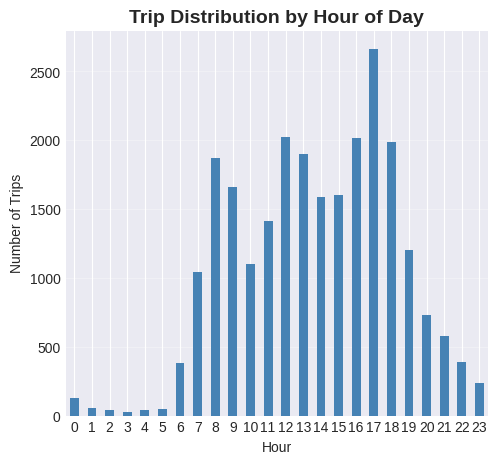

In [43]:
import os
os.makedirs('figures', exist_ok=True)

# hourly trip distribution
plt.figure(figsize=(12, 5))
hourly_trips = trips.groupby('hour').size()
plt.subplot(1, 2, 1)
hourly_trips.plot(kind='bar', color='steelblue')
plt.title('Trip Distribution by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour')
plt.ylabel('Number of Trips')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

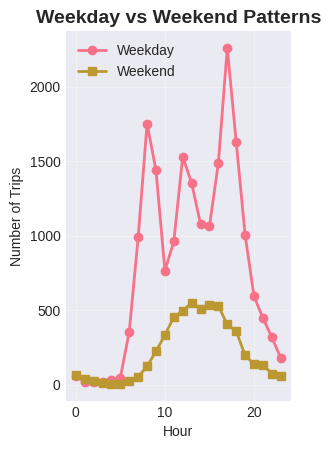

In [44]:
# weekday vs weekend patterns
plt.subplot(1, 2, 2)
weekday_hourly = trips[trips['is_weekend']==0].groupby('hour').size()
weekend_hourly = trips[trips['is_weekend']==1].groupby('hour').size()
plt.plot(weekday_hourly.index, weekday_hourly.values, marker='o', label='Weekday', linewidth=2)
plt.plot(weekend_hourly.index, weekend_hourly.values, marker='s', label='Weekend', linewidth=2)
plt.title('Weekday vs Weekend Patterns', fontsize=14, fontweight='bold')
plt.xlabel('Hour')
plt.ylabel('Number of Trips')
plt.legend()
plt.grid(True, alpha=0.3)

#plt.tight_layout()
#plt.savefig('figures/01_temporal_patterns.png', dpi=300, bbox_inches='tight')
#print("Saved: figures/01_temporal_patterns.png")
#plt.close()

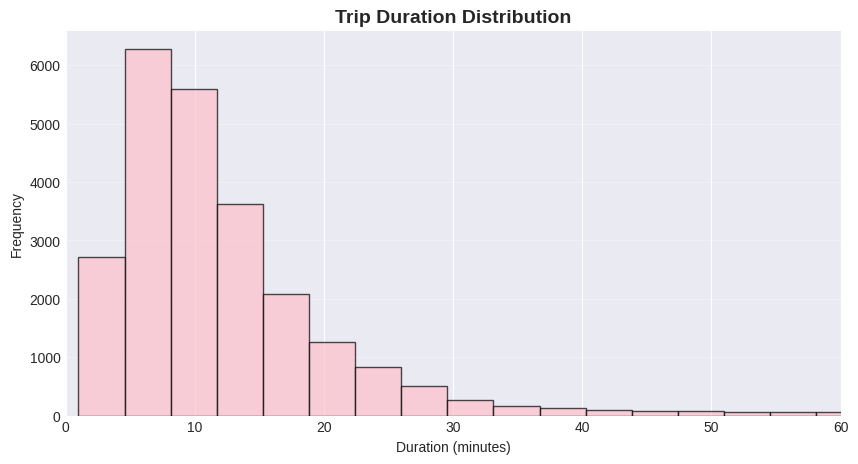

In [45]:
# trip duration distribution
plt.figure(figsize=(10, 5))
plt.hist(trips['duration_minutes'], bins=50, color='pink', edgecolor='black', alpha=0.7)
plt.title('Trip Duration Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.xlim(0, 60)  # Focus on trips under 60 minutes
plt.grid(axis='y', alpha=0.3)

#plt.savefig('figures/02_duration_distribution.png', dpi=300, bbox_inches='tight')
#print("Saved: figures/02_duration_distribution.png")
#plt.close()

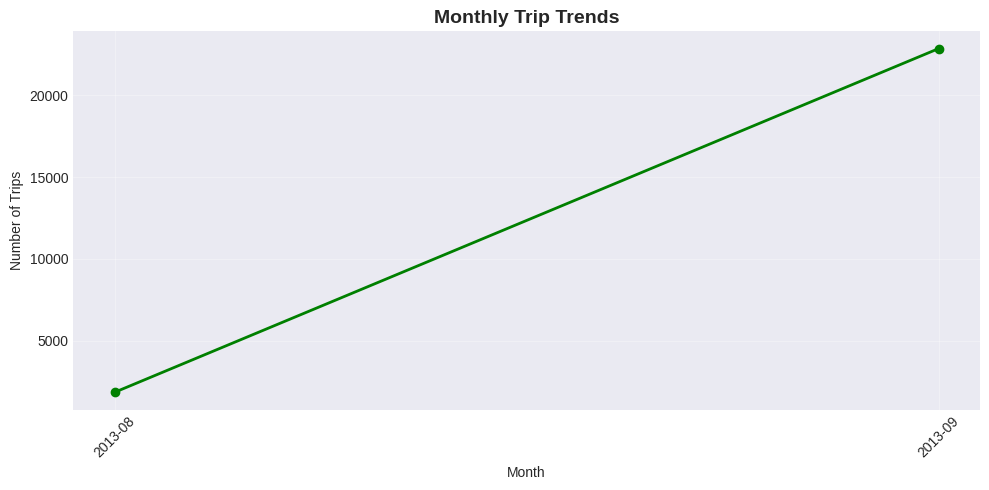

In [46]:
# monthly trends
plt.figure(figsize=(10, 5))
monthly_trips = trips.groupby(['year', 'month']).size().reset_index(name='count')
monthly_trips['year_month'] = monthly_trips['year'].astype(str) + '-' + monthly_trips['month'].astype(str).str.zfill(2)
plt.plot(range(len(monthly_trips)), monthly_trips['count'], marker='o', linewidth=2, color='green')
plt.title('Monthly Trip Trends', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.xticks(range(len(monthly_trips)), monthly_trips['year_month'], rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

#plt.savefig('figures/03_monthly_trends.png', dpi=300, bbox_inches='tight')
#print("Saved: figures/03_monthly_trends.png")
#plt.close()

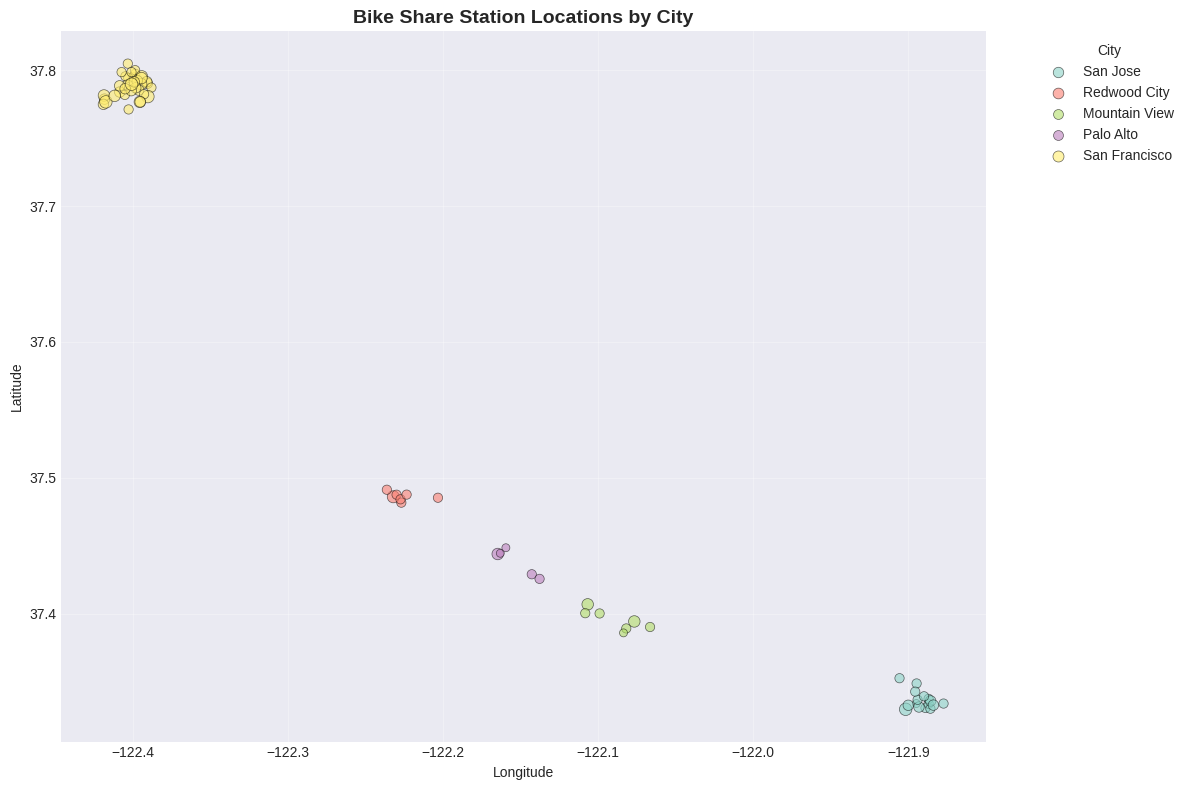

In [47]:
# station locations by city
plt.figure(figsize=(12, 8))
cities = stations['city'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(cities)))

for i, city in enumerate(cities):
    city_stations = stations[stations['city'] == city]
    plt.scatter(city_stations['long'], city_stations['lat'],
               s=city_stations['dock_count']*3,
               alpha=0.6,
               c=[colors[i]],
               label=city,
               edgecolors='black',
               linewidth=0.5)

plt.title('Bike Share Station Locations by City', fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

#plt.savefig('figures/04_station_map.png', dpi=300, bbox_inches='tight')
#print("Saved: figures/04_station_map.png")
#plt.close()


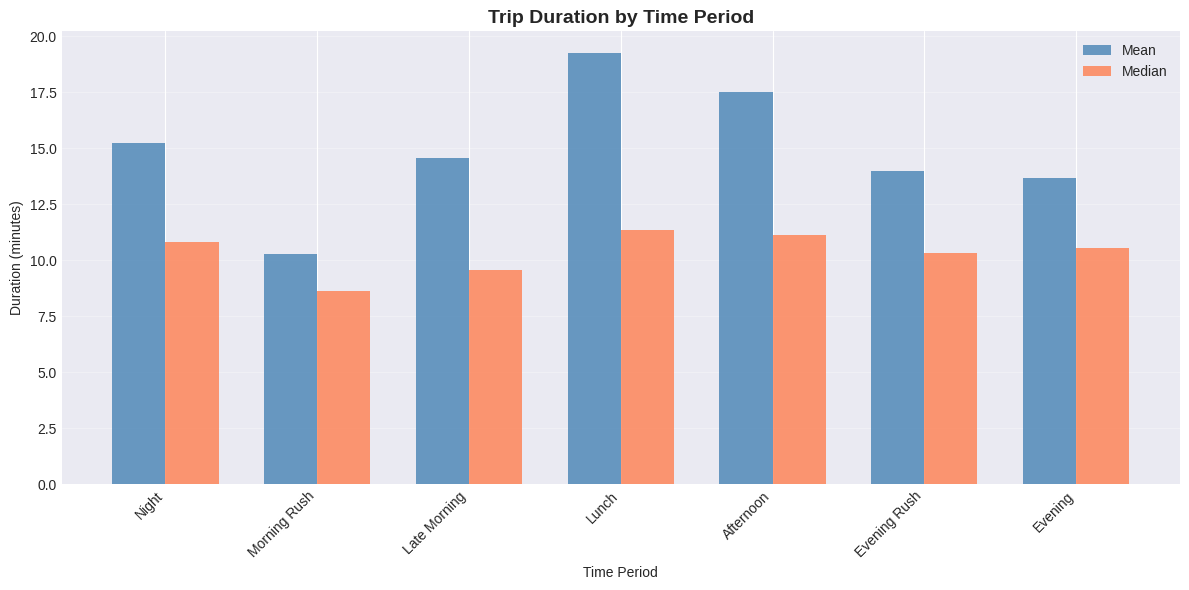

In [48]:
#trip Duration by Time Period
plt.figure(figsize=(12, 6))
time_period_order = ['Night', 'Morning Rush', 'Late Morning', 'Lunch', 'Afternoon', 'Evening Rush', 'Evening']
duration_by_period = trips.groupby('time_period')['duration_minutes'].agg(['mean', 'median', 'std'])
duration_by_period = duration_by_period.reindex(time_period_order)

x = np.arange(len(duration_by_period))
width = 0.35

plt.bar(x - width/2, duration_by_period['mean'], width, label='Mean', alpha=0.8, color='steelblue')
plt.bar(x + width/2, duration_by_period['median'], width, label='Median', alpha=0.8, color='coral')

plt.xlabel('Time Period')
plt.ylabel('Duration (minutes)')
plt.title('Trip Duration by Time Period', fontsize=14, fontweight='bold')
plt.xticks(x, duration_by_period.index, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

#plt.savefig('figures/05_duration_by_time_period.png', dpi=300, bbox_inches='tight')
#print("✓ Saved: figures/05_duration_by_time_period.png")
#plt.close()


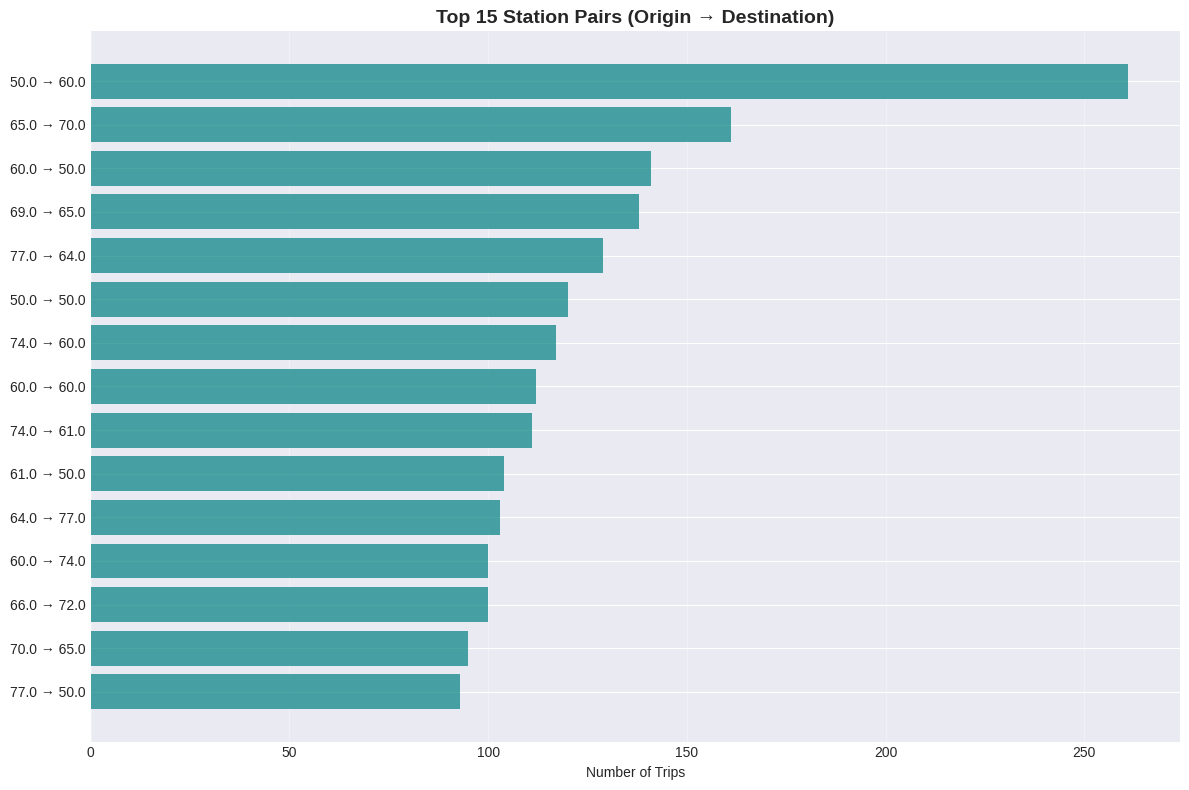

In [49]:
# top Station Pairs (Origin-Destination)
plt.figure(figsize=(12, 8))
trip_pairs = trips.groupby(['start_station_id', 'end_station_id']).size().reset_index(name='count')
trip_pairs = trip_pairs.sort_values('count', ascending=False).head(15)

# create readable labels
trip_pairs['pair_label'] = trip_pairs['start_station_id'].astype(str) + ' → ' + trip_pairs['end_station_id'].astype(str)

plt.barh(range(len(trip_pairs)), trip_pairs['count'], color='teal', alpha=0.7)
plt.yticks(range(len(trip_pairs)), trip_pairs['pair_label'])
plt.xlabel('Number of Trips')
plt.title('Top 15 Station Pairs (Origin → Destination)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

#plt.savefig('figures/06_top_station_pairs.png', dpi=300, bbox_inches='tight')
#print("✓ Saved: figures/06_top_station_pairs.png")
#plt.close()

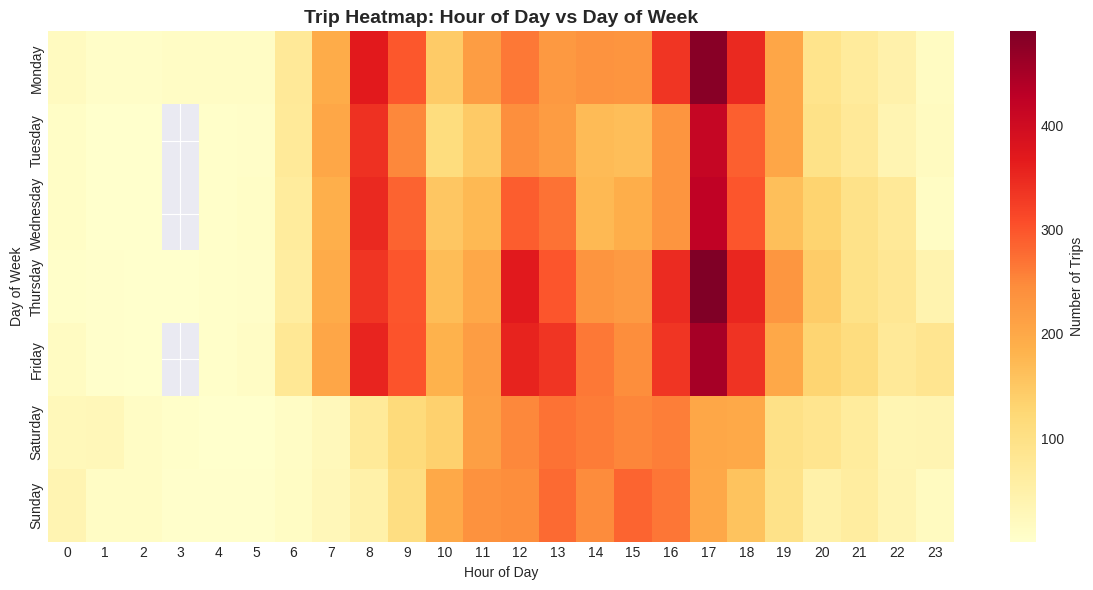

In [50]:
# heatmap: Hour vs Day of Week
plt.figure(figsize=(12, 6))
hourly_daily = trips.groupby(['day_of_week', 'hour']).size().reset_index(name='count')
heatmap_data = hourly_daily.pivot(index='day_of_week', columns='hour', values='count')

# reorder days
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data.index = day_names

sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, fmt='d', cbar_kws={'label': 'Number of Trips'})
plt.title('Trip Heatmap: Hour of Day vs Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()

#plt.savefig('figures/07_hourly_daily_heatmap.png', dpi=300, bbox_inches='tight')
#print("Saved: figures/07_hourly_daily_heatmap.png")
#plt.close()

In [51]:
import folium
from folium.plugins import HeatMap, MarkerCluster

In [52]:
# station Map with Clustering
m1 = folium.Map(location=[stations['lat'].mean(), stations['long'].mean()],
                zoom_start=11,
                tiles='OpenStreetMap')

marker_cluster = MarkerCluster().add_to(m1)

# Add each station as a marker
for idx, station in stations.iterrows():
    # Get trip count for this station
    station_trips = len(trips[trips['start_station_id'] == station['id']])

    folium.Marker(
        location=[station['lat'], station['long']],
        popup=f"<b>{station['name']}</b><br>"
              f"City: {station['city']}<br>"
              f"Docks: {station['dock_count']}<br>"
              f"Total Trips: {station_trips:,}",
        tooltip=station['name'],
        icon=folium.Icon(color='red', icon='bicycle', prefix='fa')
    ).add_to(marker_cluster)

m1
#m1.save('figures/map_01_stations_clustered.html')
#print("✓ Saved: figures/map_01_stations_clustered.html")

In [53]:
m1b = folium.Map(location=[stations['lat'].mean(), stations['long'].mean()],
                 zoom_start=11,
                 tiles='OpenStreetMap')

# Color code by activity level
trip_counts = trips.groupby('start_station_id').size()

for idx, station in stations.iterrows():
    station_trips = trip_counts.get(station['id'], 0)

    # Determine color based on activity
    if station_trips > 10000:
        color = 'red'
        activity = 'High'
    elif station_trips > 5000:
        color = 'orange'
        activity = 'Medium'
    elif station_trips > 1000:
        color = 'blue'
        activity = 'Low'
    else:
        color = 'gray'
        activity = 'Very Low'

    folium.CircleMarker(
        location=[station['lat'], station['long']],
        radius=8,
        popup=folium.Popup(f"<b>{station['name']}</b><br>"
              f"City: {station['city']}<br>"
              f"Docks: {station['dock_count']}<br>"
              f"Total Trips: {station_trips:,}<br>"
              f"Activity: {activity}", max_width=300),
        tooltip=f"{station['name']}: {station_trips:,} trips",
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.7,
        weight=2
    ).add_to(m1b)

m1b.get_root().html.add_child(folium.Element(legend_html))
m1b

#m1b.save('figures/map_01b_stations_activity.html')
#print("✓ Saved: figures/map_01b_stations_activity.html")

NameError: name 'legend_html' is not defined

In [54]:
# Station Activity Heatmap
m2 = folium.Map(location=[stations['lat'].mean(), stations['long'].mean()],
                zoom_start=11,
                tiles='CartoDB positron')

# Prepare data for heatmap: [lat, lon, weight]
heat_data = []
for idx, station in stations.iterrows():
    station_trips = len(trips[trips['start_station_id'] == station['id']])
    if station_trips > 0:
        heat_data.append([station['lat'], station['long'], station_trips])

HeatMap(heat_data,
        radius=15,
        blur=25,
        max_zoom=13,
        gradient={0.4: 'blue', 0.6: 'lime', 0.8: 'orange', 1.0: 'red'}).add_to(m2)


m2

#m2.save('figures/map_02_activity_heatmap.html')
#print("✓ Saved: figures/map_02_activity_heatmap.html")

In [55]:
# 5b.3 Stations Colored by City
m3 = folium.Map(location=[stations['lat'].mean(), stations['long'].mean()],
                zoom_start=10,
                tiles='OpenStreetMap')

# Color mapping for cities
city_colors = {
    'San Francisco': 'blue',
    'Redwood City': 'red',
    'Palo Alto': 'green',
    'Mountain View': 'orange',
    'San Jose': 'purple'
}

for idx, station in stations.iterrows():
    station_trips = len(trips[trips['start_station_id'] == station['id']])
    city = station['city']
    color = city_colors.get(city, 'gray')

    folium.CircleMarker(
        location=[station['lat'], station['long']],
        radius=station['dock_count'] / 3,  # Size based on capacity
        popup=f"<b>{station['name']}</b><br>"
              f"City: {city}<br>"
              f"Docks: {station['dock_count']}<br>"
              f"Trips: {station_trips:,}",
        tooltip=station['name'],
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.6,
        weight=2
    ).add_to(m3)

m3

#m3.save('figures/map_03_stations_by_city.html')
#print("✓ Saved: figures/map_03_stations_by_city.html")


In [56]:
# Top Routes Visualization
m4 = folium.Map(location=[stations['lat'].mean(), stations['long'].mean()], zoom_start=12,
                tiles='CartoDB positron')

# Get top 20 routes (exclude same-station trips)
top_routes = trips[trips['start_station_id'] != trips['end_station_id']].groupby(['start_station_id', 'end_station_id']).size().reset_index(name='count')
top_routes = top_routes.sort_values('count', ascending=False).head(20)


# Merge with station coordinates
top_routes = top_routes.merge(
    stations[['id', 'lat', 'long', 'name']].rename(columns={'id': 'start_station_id', 'lat': 'start_lat', 'long': 'start_long', 'name': 'start_name'}),
    on='start_station_id',
    how='left'
)
top_routes = top_routes.merge(
    stations[['id', 'lat', 'long', 'name']].rename(columns={'id': 'end_station_id', 'lat': 'end_lat', 'long': 'end_long', 'name': 'end_name'}),
    on='end_station_id',
    how='left'
)

# Remove any routes with missing coordinates
top_routes = top_routes.dropna(subset=['start_lat', 'start_long', 'end_lat', 'end_long'])


# Draw lines for routes with color gradient
max_count = top_routes['count'].max()
min_count = top_routes['count'].min()

for idx, route in top_routes.iterrows():
    # Line thickness and opacity based on trip count
    weight = 2 + (route['count'] / max_count) * 6
    opacity = 0.5 + (route['count'] / max_count) * 0.4

    # Color gradient from yellow (low) to red (high)
    color_intensity = (route['count'] - min_count) / (max_count - min_count)
    if color_intensity > 0.7:
        color = 'darkred'
    elif color_intensity > 0.4:
        color = 'red'
    elif color_intensity > 0.2:
        color = 'orange'
    else:
        color = 'yellow'

    # Draw the route line
    folium.PolyLine(
        locations=[[route['start_lat'], route['start_long']],
                   [route['end_lat'], route['end_long']]],
        weight=weight,
        color=color,
        opacity=opacity,
        popup=folium.Popup(f"<b>Route:</b><br>{route['start_name']}<br>→<br>{route['end_name']}<br><b>{route['count']:,} trips</b>", max_width=300),
        tooltip=f"{route['count']:,} trips"
    ).add_to(m4)

    # Add arrow marker at midpoint to show direction
    mid_lat = (route['start_lat'] + route['end_lat']) / 2
    mid_long = (route['start_long'] + route['end_long']) / 2

    folium.CircleMarker(
        location=[mid_lat, mid_long],
        radius=3,
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.8,
        weight=1
    ).add_to(m4)

# Add start and end stations as larger circles
stations_in_routes = set(top_routes['start_station_id'].unique()) | set(top_routes['end_station_id'].unique())

for station_id in stations_in_routes:
    station = stations[stations['id'] == station_id].iloc[0]

    # Count how many top routes involve this station
    route_count = len(top_routes[(top_routes['start_station_id'] == station_id) |
                                  (top_routes['end_station_id'] == station_id)])

    folium.CircleMarker(
        location=[station['lat'], station['long']],
        radius=6 + route_count,
        color='blue',
        fill=True,
        fillColor='lightblue',
        fillOpacity=0.9,
        weight=2,
        popup=folium.Popup(f"<b>{station['name']}</b><br>In {route_count} top routes", max_width=200),
        tooltip=station['name']
    ).add_to(m4)

# Add legend
legend_html = '''
<div style="position: fixed;
     top: 10px; right: 10px; width: 200px;
     background-color: white; border:2px solid grey; z-index:9999;
     font-size:12px; padding: 10px">
<b>Top 20 Routes</b><br>
Line thickness = trip volume<br><br>
<b>Route Colors:</b><br>
<span style="color:darkred; font-size:20px;">━</span> Very High<br>
<span style="color:red; font-size:20px;">━</span> High<br>
<span style="color:orange; font-size:20px;">━</span> Medium<br>
<span style="color:yellow; font-size:20px;">━</span> Lower<br><br>
<span style="color:blue;">●</span> Major Hub Stations
</div>
'''
m4.get_root().html.add_child(folium.Element(legend_html))

# Add title
title_html = '''
<div style="position: fixed;
     top: 10px; left: 50px; width: 280px; height: 60px;
     background-color: white; border:2px solid grey; z-index:9999;
     font-size:14px; padding: 10px">
<b>Top 20 Most Popular Routes</b><br>
🔍 Hover over lines for trip counts<br>
📍 Click for route details
</div>
'''
m4.get_root().html.add_child(folium.Element(title_html))
m4
#m4.save('figures/map_04_top_routes.html')
#print("Saved: figures/map_04_top_routes.html")


### station-level aggregations:

In [57]:
# create hourly demand profile for each station
station_hourly_profile = trips.groupby(['start_station_id', 'hour']).size().unstack(fill_value=0)

print(f"Station hourly profiles created: {station_hourly_profile.shape}")
print(f"Stations: {len(station_hourly_profile)}")
print(f"Hours: {station_hourly_profile.shape[1]}")


Station hourly profiles created: (64, 24)
Stations: 64
Hours: 24


In [58]:
# create daily profile
station_daily_profile = trips.groupby(['start_station_id', 'day_of_week']).size().unstack(fill_value=0)

print(f"Station daily profiles created: {station_daily_profile.shape}")

Station daily profiles created: (64, 7)


In [59]:
# calculate aggregate features for each station
station_features = pd.DataFrame()

# total trips from each station
station_features['total_trips'] = trips.groupby('start_station_id').size()


In [60]:
# average trip duration from each station
station_features['avg_duration'] = trips.groupby('start_station_id')['duration_minutes'].mean()

# weekend ratio (percentage of trips on weekends)
weekend_trips_by_station = trips[trips['is_weekend']==1].groupby('start_station_id').size()
station_features['weekend_ratio'] = (weekend_trips_by_station / station_features['total_trips']).fillna(0)

In [61]:
# Morning vs Evening ratio
morning_trips = trips[trips['hour'].between(6, 9)].groupby('start_station_id').size()
evening_trips = trips[trips['hour'].between(17, 20)].groupby('start_station_id').size()
station_features['morning_trips'] = morning_trips
station_features['evening_trips'] = evening_trips
station_features['morning_evening_ratio'] = (morning_trips / (morning_trips + evening_trips)).fillna(0)

In [62]:
# peak hour identification (which hour has most trips)
station_features['peak_hour'] = trips.groupby('start_station_id')['hour'].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else x.mean())


In [63]:
# Trip variance (how consistent is demand)
station_features['trip_std'] = trips.groupby('start_station_id')['hour'].agg(lambda x: x.value_counts().std())


In [64]:
stations.head(2)

,id,name,lat,long,dock_count,city,installation_date
0,2,San Jose Diridon Caltrain Station,37.329732,-121.901782,27,San Jose,8/6/2013
1,3,San Jose Civic Center,37.330698,-121.888979,15,San Jose,8/5/2013


In [65]:
# Merge with station location data
# Station columns: id, name, lat, long, dock_count, city, installation_date
# Drop overlapping columns first if they exist (from re-running the code)
overlap_cols = ['name', 'lat', 'long', 'dock_count', 'city']
station_features = station_features.drop(columns=[col for col in overlap_cols if col in station_features.columns])

# Now merge
station_features = station_features.join(stations.set_index('id')[overlap_cols], how='left')

print(f"Station aggregate features created")
print(f"\nFeature columns: {station_features.columns.tolist()}")

Station aggregate features created

Feature columns: ['total_trips', 'avg_duration', 'weekend_ratio', 'morning_trips', 'evening_trips', 'morning_evening_ratio', 'peak_hour', 'trip_std', 'name', 'lat', 'long', 'dock_count', 'city']


In [66]:
station_features.head(2)

,total_trips,avg_duration,weekend_ratio,morning_trips,evening_trips,morning_evening_ratio,peak_hour,trip_std,name,lat,long,dock_count,city
start_station_id,,,,,,,,,,,,,
2.0,299,9.957971,0.163880,114.0,94,0.548077,8,15.296747,San Jose Diridon Caltrain Station,37.329732,-121.901782,27,San Jose
3.0,61,22.665027,0.245902,5.0,18,0.217391,12,2.340517,San Jose Civic Center,37.330698,-121.888979,15,San Jose


In [67]:
# Save processed data

trips.to_csv('../Downloads/Bike_share_dataset/trips_processed.csv', index=False)
station_features.to_csv('../Downloads/Bike_share_dataset/station_features.csv')
station_hourly_profile.to_csv('../Downloads/Bike_share_dataset/station_hourly_profile.csv')
print("Processed data saved to 'data_processed/' directory")

OSError: Cannot save file into a non-existent directory: '../Downloads/Bike_share_dataset'

### correlation analysis

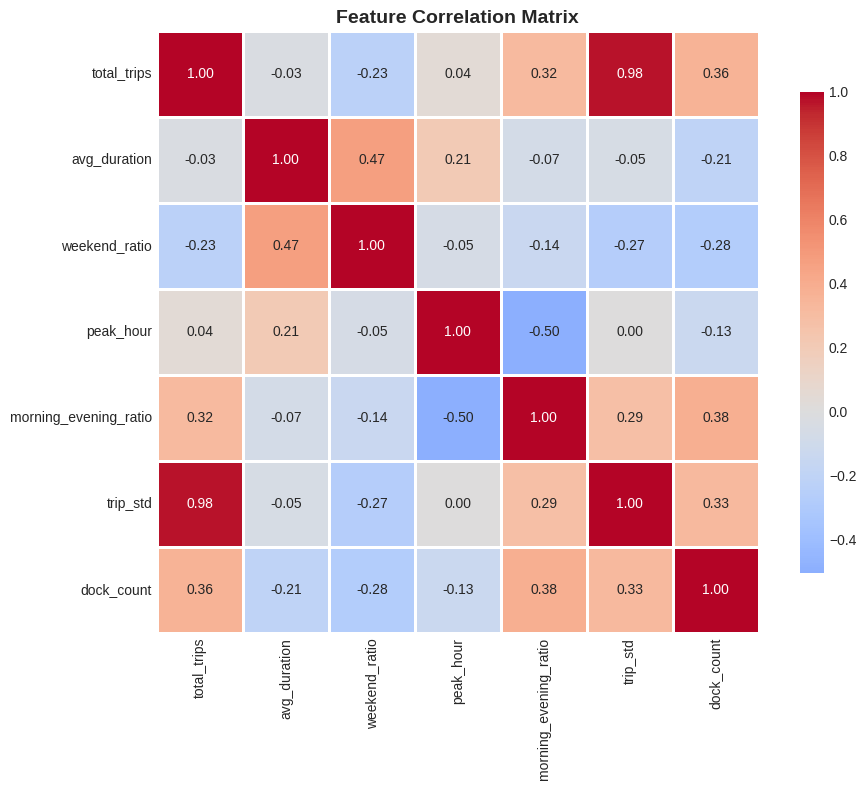

In [68]:
# Select numeric features for correlation
numeric_features = ['total_trips', 'avg_duration', 'weekend_ratio', 'peak_hour',
                   'morning_evening_ratio', 'trip_std', 'dock_count']

correlation_matrix = station_features[numeric_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#plt.savefig('figures/08_correlation_matrix.png', dpi=300, bbox_inches='tight')
#print("✓ Saved: figures/08_correlation_matrix.png")
#plt.close()

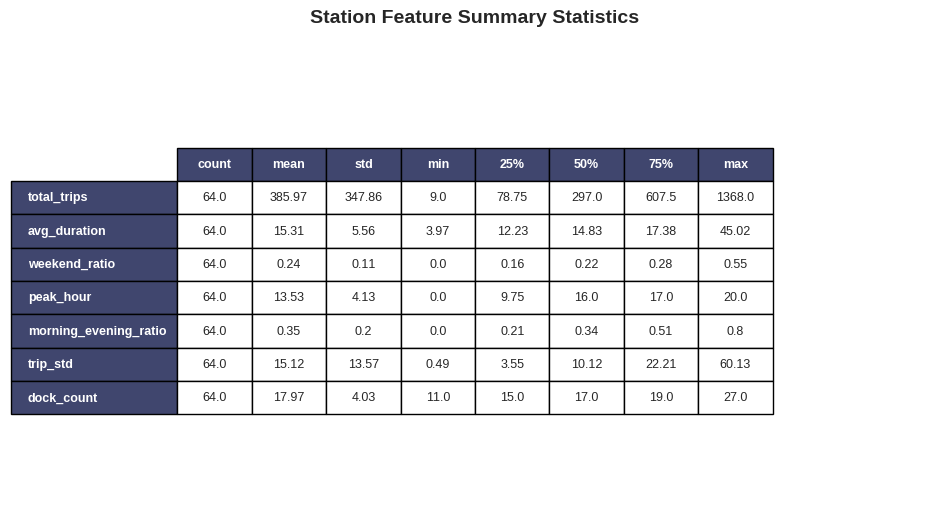

In [69]:
summary_stats = station_features[numeric_features].describe()

# Create a nice table visualization
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('tight')
ax.axis('off')

table_data = summary_stats.round(2).T
table = ax.table(cellText=table_data.values,
                rowLabels=table_data.index,
                colLabels=table_data.columns,
                cellLoc='center',
                loc='center',
                colWidths=[0.08]*len(table_data.columns))

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Style header
for i in range(len(table_data.columns)):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style row labels
for i in range(1, len(table_data.index)+1):
    table[(i, -1)].set_facecolor('#40466e')
    table[(i, -1)].set_text_props(weight='bold', color='white')

plt.title('Station Feature Summary Statistics', fontsize=14, fontweight='bold', pad=20)
plt.show()

#plt.savefig('figures/09_summary_statistics.png', dpi=300, bbox_inches='tight')
#print("Saved: figures/09_summary_statistics.png")
#plt.close()

In [70]:
# summary

print("PREPROCESSING COMPLETE - SUMMARY")

print(f"Total trips after cleaning: {len(trips):,}")
print(f"Total stations: {len(stations)}")
print(f"Date range: {trips['start_date'].min()} to {trips['start_date'].max()}")
print(f"Average trip duration: {trips['duration_minutes'].mean():.1f} minutes")


PREPROCESSING COMPLETE - SUMMARY
Total trips after cleaning: 24,702
Total stations: 70
Date range: 2013-08-29 09:08:00 to 2013-09-30 19:16:00
Average trip duration: 15.2 minutes


### Spatio-Temporal Feature Engineering & Graph Construction for ST-GAT

In [71]:

# Create hourly demand time series for each station

# Round timestamps to nearest hour
trips['start_hour'] = trips['start_date'].dt.floor('H')

# Aggregate: count trips per station per hour
demand_ts = trips.groupby(['start_hour', 'start_station_id']).size().unstack(fill_value=0)

# Ensure continuous hourly index (including zero-demand hours)
full_index = pd.date_range(demand_ts.index.min(), demand_ts.index.max(), freq='H')
demand_ts = demand_ts.reindex(full_index, fill_value=0)

print("Hourly demand shape:", demand_ts.shape)
demand_ts.head()


Hourly demand shape: (779, 64)


start_station_id,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,...,68.0,69.0,70.0,71.0,72.0,73.0,74.0,75.0,76.0,77.0
2013-08-29 09:00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2013-08-29 10:00:00,0,0,0,0,0,0,0,0,2,0,...,0,0,0,0,0,1,0,1,1,0
2013-08-29 11:00:00,0,0,0,0,0,0,0,0,4,0,...,0,4,9,0,0,3,1,1,0,0
2013-08-29 12:00:00,0,0,0,1,0,0,0,2,1,2,...,4,6,0,1,5,2,3,2,4,6
2013-08-29 13:00:00,1,1,1,1,1,0,2,3,0,0,...,3,3,1,1,1,0,2,3,3,3


In [72]:
# Filter to San Francisco stations only
sf_stations_list = stations[stations['city'] == 'San Francisco']['id'].values

# Filter demand_ts to SF stations only
sf_station_cols = [col for col in demand_ts.columns if col in sf_stations_list]
demand_ts_sf = demand_ts[sf_station_cols].copy()

print(f"Original stations: {demand_ts.shape[1]}")
print(f"SF stations: {demand_ts_sf.shape[1]}")

# Filter to weekdays only (Monday-Friday)
is_weekday = demand_ts_sf.index.dayofweek < 5
demand_ts_weekday = demand_ts_sf[is_weekday].copy()

print(f"Original hours: {len(demand_ts_sf):,}")
print(f"Weekday hours: {len(demand_ts_weekday):,}")

Original stations: 64
SF stations: 34
Original hours: 779
Weekday hours: 539


In [131]:
# Identify top 15 most active stations (MORE AGGRESSIVE)
station_activity = demand_ts_weekday.sum().sort_values(ascending=False)

print("Top 20 stations by weekday trip volume:")
for i, (station_id, count) in enumerate(station_activity.head(20).items(), 1):
    station_name = stations[stations['id'] == station_id]['name'].values
    if len(station_name) > 0:
        print(f"{i:2d}. Station {int(station_id):2d}: {int(count):6,} trips - {station_name[0]}")

# Keep top 15 stations only (not 25)
top_stations = station_activity.nlargest(15).index.tolist()

# ALSO filter to peak hours only (7-10am, 4-7pm)
peak_hours = demand_ts_weekday.index.hour.isin([7, 8, 9, 16, 17, 18])
# Keep ALL SF weekday data (no station filtering, no hour filtering)
# Just filter to SF and weekdays
demand_ts_filtered = demand_ts_weekday.copy()

print(f"Using ALL SF weekday data:")
print(f"Stations: {demand_ts_filtered.shape[1]}")
print(f"Hours: {len(demand_ts_filtered):,}")

# Replace demand_ts
demand_ts = demand_ts_filtered
STATIONS_TO_KEEP = demand_ts.columns.tolist()
FILTERED_INDEX = demand_ts.index

Top 20 stations by weekday trip volume:
 1. Station 70:  1,138 trips - San Francisco Caltrain (Townsend at 4th)
 2. Station 50:    976 trips - Harry Bridges Plaza (Ferry Building)
 3. Station 60:    880 trips - Embarcadero at Sansome
 4. Station 77:    872 trips - Market at Sansome
 5. Station 74:    685 trips - Steuart at Market
 6. Station 61:    636 trips - 2nd at Townsend
 7. Station 66:    634 trips - South Van Ness at Market
 8. Station 65:    631 trips - Townsend at 7th
 9. Station 64:    627 trips - 2nd at South Park
10. Station 69:    607 trips - San Francisco Caltrain 2 (330 Townsend)
11. Station 76:    594 trips - Market at 4th
12. Station 55:    571 trips - Temporary Transbay Terminal (Howard at Beale)
13. Station 67:    514 trips - Market at 10th
14. Station 73:    503 trips - Grant Avenue at Columbus Avenue
15. Station 62:    500 trips - 2nd at Folsom
16. Station 39:    488 trips - Powell Street BART
17. Station 63:    461 trips - Howard at 2nd
18. Station 49:    454 trip

In [132]:
# Create hourly END-station demand time series

# Round end timestamps to nearest hour
trips['end_hour'] = trips['end_date'].dt.floor('H')

# Aggregate: count trips per END station per hour
end_demand_ts = (
    trips
    .groupby(['end_hour', 'end_station_id'])
    .size()
    .unstack(fill_value=0)
)

# Reindex to ensure continuous hourly index
end_demand_ts = end_demand_ts.reindex(demand_ts.index, fill_value=0)

# Ensure station ordering matches start-demand
end_demand_ts = end_demand_ts[demand_ts.columns]

print("End-demand shape:", end_demand_ts.shape)
end_demand_ts.head()


End-demand shape: (539, 34)


end_station_id,39.0,41.0,42.0,45.0,46.0,47.0,48.0,49.0,50.0,51.0,...,68.0,69.0,70.0,71.0,72.0,73.0,74.0,75.0,76.0,77.0
2013-08-29 09:00:00,0,0,0,1,0,0,0,0,0,0,...,0,5,0,0,0,0,0,0,0,0
2013-08-29 10:00:00,0,1,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,1,0,0,0
2013-08-29 11:00:00,0,1,0,1,0,2,1,0,0,0,...,0,3,1,0,1,0,1,0,0,0
2013-08-29 12:00:00,0,4,1,6,1,5,2,2,10,1,...,2,3,1,1,3,0,4,5,5,4
2013-08-29 13:00:00,4,2,3,1,2,4,6,2,1,2,...,0,1,4,1,2,0,1,2,6,5


In [133]:
# Apply filtering to end_demand_ts
end_demand_ts = end_demand_ts.reindex(FILTERED_INDEX, fill_value=0)[STATIONS_TO_KEEP].copy()

print(f"✓ end_demand_ts filtered: {end_demand_ts.shape}")
print(f"✓ Matches demand_ts: {demand_ts.shape}")

✓ end_demand_ts filtered: (539, 34)
✓ Matches demand_ts: (539, 34)


In [134]:
# Align station coordinates to station demand columns

# Reindex stations to match demand_ts ordering
station_coords = stations.set_index('id').loc[demand_ts.columns][['lat', 'long']]

print("Station coordinate sample:")
station_coords.head()


Station coordinate sample:


,lat,long
start_station_id,,
39,37.783871,-122.408433
41,37.795001,-122.399970
42,37.797280,-122.398436
45,37.794231,-122.402923
46,37.795425,-122.404767


In [135]:
# Apply filtering to station_coords
station_coords = station_coords.loc[STATIONS_TO_KEEP].copy()

print(f"✓ station_coords filtered: {station_coords.shape}")

✓ station_coords filtered: (34, 2)


In [136]:
# Build K-Nearest Neighbors adjacency matrix
# Convert coordinates to radians for haversine calculation
coords_rad = np.radians(station_coords[['lat', 'long']].values)

# Build 5-nearest neighbor graph
k = 5
nbrs = NearestNeighbors(n_neighbors=k, metric='haversine').fit(coords_rad)
distances, indices = nbrs.kneighbors(coords_rad)

# Initialize adjacency matrix
num_nodes = len(station_coords)
A = np.zeros((num_nodes, num_nodes))

for i, row in enumerate(indices):
    A[i, row] = 1

# Include self-connections
np.fill_diagonal(A, 1)

print("Adjacency matrix shape:", A.shape)
A[:5, :5]

Adjacency matrix shape: (34, 34)


array([[1., 0., 0., 0., 0.],
       [0., 1., 1., 1., 0.],
       [0., 1., 1., 0., 0.],
       [0., 1., 1., 1., 1.],
       [0., 1., 1., 1., 1.]])

In [137]:
# Normalization of Start-Demand
demand_norm = demand_ts.copy()

for col in demand_ts.columns:
    col_std = demand_ts[col].std()
    col_mean = demand_ts[col].mean()

    if col_std == 0:
             demand_norm[col] = 0.0
    else:
        demand_norm[col] = (demand_ts[col] - col_mean) / col_std

demand_norm.head()


start_station_id,39.0,41.0,42.0,45.0,46.0,47.0,48.0,49.0,50.0,51.0,...,68.0,69.0,70.0,71.0,72.0,73.0,74.0,75.0,76.0,77.0
2013-08-29 09:00:00,-0.730611,-0.609562,-0.592461,0.225726,-0.498001,-0.612512,-0.530283,-0.642166,-0.738474,-0.535287,...,-0.526153,-0.576437,-0.668072,-0.627762,-0.609455,-0.634010,-0.672653,-0.642487,-0.761970,-0.796193
2013-08-29 10:00:00,-0.730611,-0.609562,-0.592461,-0.580011,-0.498001,-0.612512,-0.530283,0.120229,-0.738474,-0.535287,...,-0.526153,-0.576437,-0.668072,-0.627762,-0.609455,0.045376,-0.672653,0.202148,-0.070553,-0.796193
2013-08-29 11:00:00,0.883321,0.250527,0.236984,-0.580011,-0.498001,0.184937,-0.530283,0.120229,0.485002,-0.535287,...,-0.526153,1.471007,2.179746,-0.627762,-0.609455,1.404150,-0.143368,0.202148,-0.761970,-0.796193
2013-08-29 12:00:00,0.076355,3.690885,0.236984,1.031462,2.342450,3.374735,1.477839,0.120229,3.339780,0.999392,...,4.240172,2.494729,-0.668072,0.296729,3.310550,0.724763,0.915201,1.046783,2.003698,2.156660
2013-08-29 13:00:00,0.883321,1.110616,1.066430,6.671619,-0.498001,-0.612512,2.147213,0.882625,0.485002,-0.535287,...,3.048591,0.959146,-0.351648,0.296729,0.174546,-0.634010,0.385916,1.891419,1.312281,0.680234


In [138]:
# Normalize end-station demand
scaler_end = StandardScaler()

end_demand_norm = pd.DataFrame(
    scaler_end.fit_transform(end_demand_ts.values),
    index=end_demand_ts.index,
    columns=end_demand_ts.columns
)

print("Normalized end-demand shape:", end_demand_norm.shape)
end_demand_norm.head()


Normalized end-demand shape: (539, 34)


end_station_id,39.0,41.0,42.0,45.0,46.0,47.0,48.0,49.0,50.0,51.0,...,68.0,69.0,70.0,71.0,72.0,73.0,74.0,75.0,76.0,77.0
2013-08-29 09:00:00,-0.689060,-0.593997,-0.611996,0.374262,-0.541530,-0.658879,-0.573229,-0.697822,-0.703365,-0.574999,...,-0.565054,1.802263,-0.702493,-0.563764,-0.633805,-0.613964,-0.684183,-0.632337,-0.753029,-0.795623
2013-08-29 10:00:00,-0.689060,0.388102,-0.611996,-0.644563,-0.541530,-0.658879,-0.573229,-0.697822,-0.703365,-0.574999,...,-0.565054,-0.086740,-0.702493,0.462819,-0.633805,-0.613964,-0.127122,-0.632337,-0.753029,-0.795623
2013-08-29 11:00:00,-0.689060,0.388102,-0.611996,0.374262,-0.541530,1.157672,0.135419,-0.697822,-0.703365,-0.574999,...,-0.565054,0.857761,-0.401982,-0.563764,0.151530,-0.613964,-0.127122,-0.632337,-0.753029,-0.795623
2013-08-29 12:00:00,-0.689060,3.334401,0.247030,5.468389,0.785219,3.882498,0.844066,0.782989,3.122204,0.298027,...,1.682653,0.857761,-0.401982,0.462819,1.722202,-0.613964,1.544063,3.726097,2.393348,1.222451
2013-08-29 13:00:00,2.072303,1.370202,1.965081,0.374262,2.111968,2.974223,3.678657,0.782989,-0.320808,1.171053,...,-0.565054,-0.086740,0.499550,0.462819,0.936866,-0.613964,-0.127122,1.111037,3.022623,1.726969


In [139]:
# Normalize daily weather
weather_scaler = StandardScaler()

weather_norm = pd.DataFrame(
    weather_scaler.fit_transform(weather_daily),
    index=weather_daily.index,
    columns=weather_daily.columns
)

print("Normalized weather shape:", weather_norm.shape)
weather_norm.head()


Normalized weather shape: (733, 5)


,mean_temperature_f,mean_humidity,mean_wind_speed_mph,precipitation_inches,cloud_cover
date,,,,,
2013-08-29,1.282607,0.583860,0.560574,-0.183691,0.715743
2013-08-30,1.651249,0.140848,-0.141021,-0.183691,-0.396853
2013-08-31,0.942322,0.342217,0.560574,-0.183691,-0.902578
2013-09-01,1.225893,-0.060521,0.482619,-0.183691,-0.295708
2013-09-02,1.339321,0.664407,0.560574,-0.183691,1.120323


In [140]:
# Create hourly temporal feature matrix

time_features = (
    trips
    .drop_duplicates(subset=['start_hour'])
    .set_index('start_hour')
    .sort_index()
)

time_features = time_features[
    ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend']
]

# Align with demand_norm index AND fill missing hours
time_features = time_features.reindex(demand_norm.index).fillna(0.0)

print("Time features shape:", time_features.shape)
print("Any NaNs in time_features:", time_features.isna().sum().sum())


Time features shape: (539, 5)
Any NaNs in time_features: 0


In [141]:
# Align normalized daily weather to hourly demand
# Hourly index from demand time series
hourly_index = demand_ts.index

# Reindex daily weather to each hour's date
weather_hourly = weather_norm.reindex(
    hourly_index.date,
    method='nearest'
)

# Restore hourly datetime index
weather_hourly.index = hourly_index

print("Weather hourly shape:", weather_hourly.shape)
weather_hourly.head()


Weather hourly shape: (539, 5)


,mean_temperature_f,mean_humidity,mean_wind_speed_mph,precipitation_inches,cloud_cover
2013-08-29 09:00:00,1.282607,0.58386,0.560574,-0.183691,0.715743
2013-08-29 10:00:00,1.282607,0.58386,0.560574,-0.183691,0.715743
2013-08-29 11:00:00,1.282607,0.58386,0.560574,-0.183691,0.715743
2013-08-29 12:00:00,1.282607,0.58386,0.560574,-0.183691,0.715743
2013-08-29 13:00:00,1.282607,0.58386,0.560574,-0.183691,0.715743


In [142]:
# Broadcast hourly weather to stations
num_nodes = demand_ts.shape[1]
num_weather_features = weather_hourly.shape[1]

# Expand weather to (time, nodes, weather_features)
weather_node = np.repeat(
    weather_hourly.values[:, np.newaxis, :],
    repeats=num_nodes,
    axis=1
)

print("Weather node tensor shape:", weather_node.shape)


Weather node tensor shape: (539, 34, 5)


In [143]:
# Create sliding windows with features
T = 12  # unchanged
X, Y = [], []

start_vals = demand_norm.values        # (time, N)
end_vals   = end_demand_norm.values    # (time, N)
time_vals  = time_features.values      # (time, F_time)
weather_vals = weather_node            # (time, N, F_weather)

N = start_vals.shape[1]

for t in range(T, len(start_vals)):
    # Demand windows
    start_window = start_vals[t-T:t]   # (T, N)
    end_window   = end_vals[t-T:t]     # (T, N)

    # Stack start + end demand → (T, N, 2)
    demand_window = np.stack(
        [start_window, end_window],
        axis=-1
    )
    # Temporal features (broadcast)
    time_window = time_vals[t-T:t]                  # (T, F_time)
    time_window = np.repeat(
        time_window[:, None, :],
        N,
        axis=1
    )                                                # (T, N, F_time)

    # Weather features (already node-level)
    weather_window = weather_vals[t-T:t]            # (T, N, F_weather)

    # Final input tensor
    X.append(
        np.concatenate(
            [demand_window, time_window, weather_window],
            axis=-1
        )
    )

    # Target: next-hour START demand
    Y.append(start_vals[t])

X = np.array(X)
Y = np.array(Y)

print("X shape:", X.shape)
print("Y shape:", Y.shape)


X shape: (527, 12, 34, 12)
Y shape: (527, 34)


In [144]:
# Chronological split for forecasting

train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

X_train, Y_train = X[:train_size], Y[:train_size]
X_val, Y_val = X[train_size:train_size+val_size], Y[train_size:train_size+val_size]
X_test, Y_test = X[train_size+val_size:], Y[train_size+val_size:]

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)


Train: (368, 12, 34, 12)
Val:   (79, 12, 34, 12)
Test:  (80, 12, 34, 12)


### ST-GAT Model Setup & Training Pipeline

In [145]:
# Convert adjacency matrix for PyTorch and normalize
# Convert adjacency matrix A to torch tensor
A_tensor = torch.tensor(A, dtype=torch.float32)

# Normalize adjacency: A_norm = D^{-1/2} A D^{-1/2}
deg = torch.sum(A_tensor, dim=1)
D_inv_sqrt = torch.diag(1.0 / torch.sqrt(deg))
A_norm = D_inv_sqrt @ A_tensor @ D_inv_sqrt

print("Adjacency matrix normalized shape:", A_norm.shape)


Adjacency matrix normalized shape: torch.Size([34, 34])


In [146]:
# Create PyTorch dataset and dataloaders
class BikeDemandDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)  # shape: (samples, T, nodes, 1)
        self.Y = torch.tensor(Y, dtype=torch.float32)  # shape: (samples, nodes)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_dataset = BikeDemandDataset(X_train, Y_train)
val_dataset   = BikeDemandDataset(X_val,   Y_val)
test_dataset  = BikeDemandDataset(X_test,  Y_test)

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

len(train_loader), len(val_loader), len(test_loader)


(23, 5, 5)

In [147]:
class STGAT(nn.Module):
    def __init__(self, num_nodes, in_features, hidden_dim=128, gat_heads=8, gru_layers=3):
        super(STGAT, self).__init__()
        self.num_nodes = num_nodes

        # BIGGER Graph attention: 8 heads, 128 hidden
        self.gat = GATConv(
            in_channels=in_features,
            out_channels=hidden_dim // gat_heads,
            heads=gat_heads,
            concat=True,
            dropout=0.3
        )

        # DEEPER GRU: 3 layers
        self.gru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=gru_layers,
            batch_first=True,
            dropout=0.3
        )

        # Output layer
        self.fc = nn.Linear(hidden_dim, num_nodes)

        # Edge index
        n_nodes = num_nodes
        edges = []
        for i in range(n_nodes):
            for j in range(i+1, n_nodes):
                edges.append([i, j])
                edges.append([j, i])
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        self.register_buffer('edge_index', edge_index)

    def forward(self, x):
        batch, T, N, F = x.shape
        outputs = []

        for t in range(T):
            xt = x[:, t, :, :].reshape(batch * N, F)
            xt = self.gat(xt, self.edge_index)
            xt = xt.reshape(batch, N, -1)
            outputs.append(xt)

        x_seq = torch.stack(outputs, dim=1)
        x_seq = x_seq.mean(dim=2)
        out, _ = self.gru(x_seq)
        out = out[:, -1, :]
        preds = self.fc(out)
        return preds

In [153]:
# Model initialization

batch_size = 16
epochs = 30

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

model = STGAT(
    num_nodes=X_train.shape[2],
    in_features=X_train.shape[-1]
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Model initialized")
print("Input features:", X_train.shape[-1])
print("Batch size:", batch_size)
print("Epochs:", epochs)
print("Device:", device)



Model initialized
Input features: 12
Batch size: 16
Epochs: 30
Device: cuda


In [154]:
Xb, Yb = next(iter(train_loader))
print("Batch X shape:", Xb.shape)
print("Batch Y shape:", Yb.shape)

with torch.no_grad():
    preds = model(Xb.to(device))

print("Prediction shape:", preds.shape)

Batch X shape: torch.Size([16, 12, 34, 12])
Batch Y shape: torch.Size([16, 34])
Prediction shape: torch.Size([16, 34])


In [155]:
print("NaNs in X_train:", np.isnan(X_train).sum())
print("NaNs in Y_train:", np.isnan(Y_train).sum())

print("Infs in X_train:", np.isinf(X_train).sum())
print("Infs in Y_train:", np.isinf(Y_train).sum())


NaNs in X_train: 0
NaNs in Y_train: 0
Infs in X_train: 0
Infs in Y_train: 0


In [156]:
# Prepare Training Loop

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    for X_batch, Y_batch in loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, Y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, Y_batch)
            total_loss += loss.item()

    return total_loss / len(loader)


for epoch in range(1, epochs + 1):
    train_loss = train_epoch(model, train_loader)
    val_loss = evaluate(model, val_loader)

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch 01 | Train Loss: 0.7428 | Val Loss: 0.9272
Epoch 02 | Train Loss: 0.6337 | Val Loss: 0.9182
Epoch 03 | Train Loss: 0.6198 | Val Loss: 0.8797
Epoch 04 | Train Loss: 0.5995 | Val Loss: 0.8471
Epoch 05 | Train Loss: 0.5876 | Val Loss: 0.8454
Epoch 06 | Train Loss: 0.5742 | Val Loss: 0.8268
Epoch 07 | Train Loss: 0.5634 | Val Loss: 0.7667
Epoch 08 | Train Loss: 0.5542 | Val Loss: 0.7516
Epoch 09 | Train Loss: 0.5441 | Val Loss: 0.8984
Epoch 10 | Train Loss: 0.5568 | Val Loss: 0.7368
Epoch 11 | Train Loss: 0.5292 | Val Loss: 0.7415
Epoch 12 | Train Loss: 0.5179 | Val Loss: 0.7265
Epoch 13 | Train Loss: 0.5137 | Val Loss: 0.7241
Epoch 14 | Train Loss: 0.5091 | Val Loss: 0.7016
Epoch 15 | Train Loss: 0.4963 | Val Loss: 0.7007
Epoch 16 | Train Loss: 0.4892 | Val Loss: 0.6995
Epoch 17 | Train Loss: 0.4801 | Val Loss: 0.6936
Epoch 18 | Train Loss: 0.4704 | Val Loss: 0.7275
Epoch 19 | Train Loss: 0.4722 | Val Loss: 0.7070
Epoch 20 | Train Loss: 0.4688 | Val Loss: 0.6964
Epoch 21 | Train Los

In [157]:
# Evaluate Training Loop

model.eval()

preds, actuals = [], []

with torch.no_grad():
    for Xb, Yb in test_loader:
        Xb = Xb.to(device)
        preds.append(model(Xb).cpu().numpy())
        actuals.append(Yb.numpy())

preds = np.vstack(preds)
actuals = np.vstack(actuals)

# --- Metrics ---
mse = np.mean((preds - actuals) ** 2)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actuals, preds)
r2 = r2_score(actuals.flatten(), preds.flatten())

print("Test MSE :", round(mse, 4))
print("Test RMSE:", round(rmse, 4))
print("Test MAE :", round(mae, 4))
print("Test R²  :", round(r2, 4))

Test MSE : 0.9557
Test RMSE: 0.9776
Test MAE : 0.6275
Test R²  : 0.327
